Question 2

Text(0.5, 1.0, 'Gamma Corrected L channel histogram')

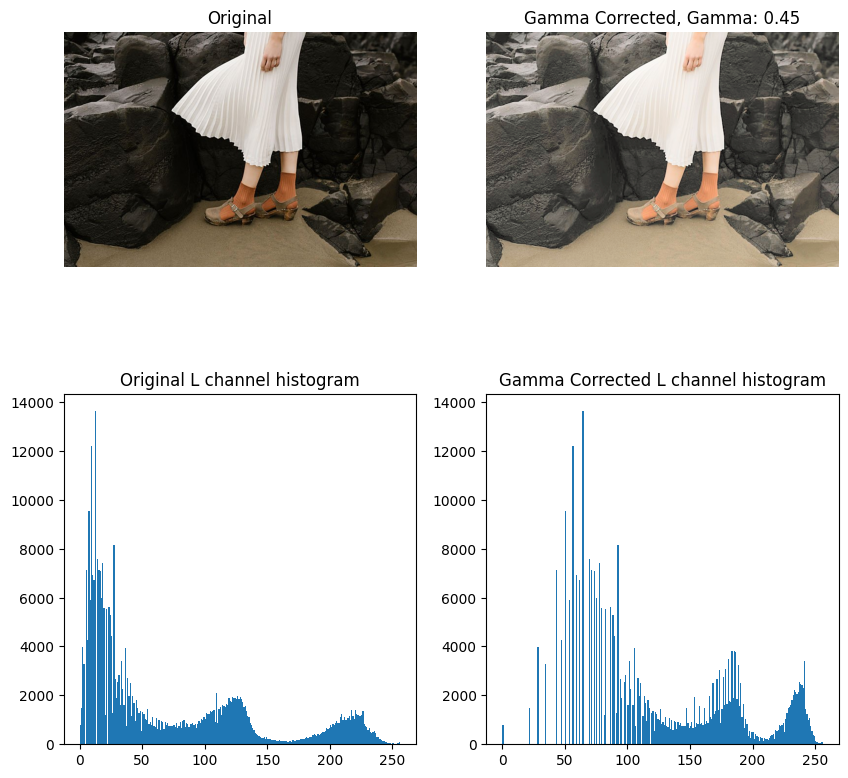

In [31]:
import cv2 as cv
import numpy as np
import sys
import matplotlib.pyplot as plt

img = cv.imread('highlights_and_shadows.jpg')
if img is None:
    print("Could not read input image")
    sys.exit(1)

gamma = 0.45

#convert iamge to LAB space
img_lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
l, a, b = cv.split(img_lab)

l_normal = l / 255.0
l_gamma = np.power(l_normal,gamma)
l_gamma_corrected = (l_gamma * 255).astype(np.uint8)

#combine to a new image
lab_new = cv.merge((l_gamma_corrected,a,b))
img_new = cv.cvtColor(lab_new, cv.COLOR_LAB2BGR)

plot, axis = plt.subplots(2,2,figsize=(10,10))

#show images
axis[0,0].imshow(cv.cvtColor(img,cv.COLOR_BGR2RGB))
axis[0,0].axis('off')
axis[0,0].set_title('Original')

axis[0,1].imshow(cv.cvtColor(img_new,cv.COLOR_BGR2RGB))
axis[0,1].axis('off')
axis[0,1].set_title(f'Gamma Corrected, Gamma: {gamma}')

#show histogram
axis[1,0].hist(l.flatten(), bins=256, range=[0,256])
axis[1,0].set_title('Original L channel histogram')

axis[1,1].hist(l_gamma_corrected.flatten(), bins=256, range=[0,256])
axis[1,1].set_title('Gamma Corrected L channel histogram')